<a href="https://colab.research.google.com/github/AmirNabiyev30/Elder_Fraud_Protection/blob/main/Elder_Fraud_Protection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub[pandas-datasets] --quiet

In [2]:
import kagglehub
import pandas as pd
import numpy as np
from google.colab import files
import os
import seaborn as sns
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk

In [ ]:
nltk.download('punkt')
nltk.download('wordnet')

In [3]:
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ayonuddin","key":"8720f5f5c8a9d92cfdabc7488fc0d96d"}'}

In [4]:
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [5]:
file_path='df.csv'
dataset_name = "akshatsharma2/the-biggest-spam-ham-phish-email-dataset-300000"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    dataset_name,
    file_path,
)

print("First 5 records:\n", df.head())

/tmp/ipykernel_1740/3939100370.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 601M/601M [00:11<00:00, 53.4MB/s]


First 5 records:
    label                                               text
0      0  wrong bill grace i ' ll forward original messa...
1      0  i have continued the hilcorp old ocean deal da...
2      0  several related issues have resulted in an inc...
3      0  one year rate for this one will be escapenumbe...
4      0  attached is the weekly deal report for escapen...


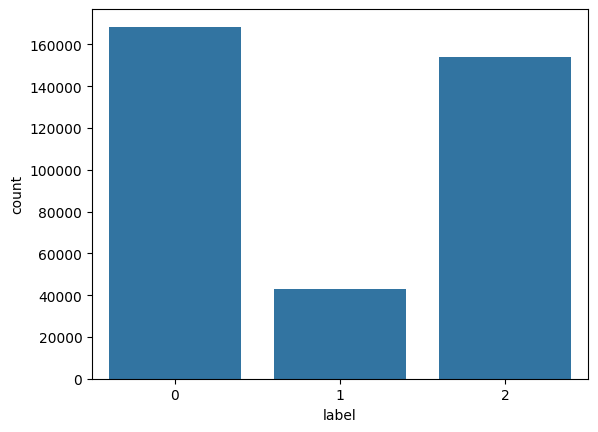

In [6]:
sns.countplot(x='label',data=df)
plt.show()


In [7]:
df.isnull().sum()

,0
label,0
text,2


In [8]:
df.dropna(inplace=True)

In [9]:
df.isnull().sum()

,0
label,0
text,0


In [10]:
df_clean = df.copy()

In [11]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [12]:
df_clean["text"] = df_clean["text"].apply(clean_text)